In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
SILVER_DIR = "../data/2_silver/"

# Load silver data
df_students = pd.read_csv(SILVER_DIR + "students_silver.csv")
df_schools = pd.read_csv(SILVER_DIR + "schools_silver.csv")
df_regions = pd.read_csv(SILVER_DIR + "regional_stats_silver.csv")

print("✅ Silver data loaded successfully")
print(f"Students : {df_students.shape}")
print(f"Schools  : {df_schools.shape}")
print(f"Regions  : {df_regions.shape}")

✅ Silver data loaded successfully
Students : (1000, 19)
Schools  : (137, 11)
Regions  : (8, 9)


=== Distribution du statut des élèves ===

status
Admis      751
Ajourné    233
Recalé      16
Name: count, dtype: int64

Taux de réussite global : 75.1%


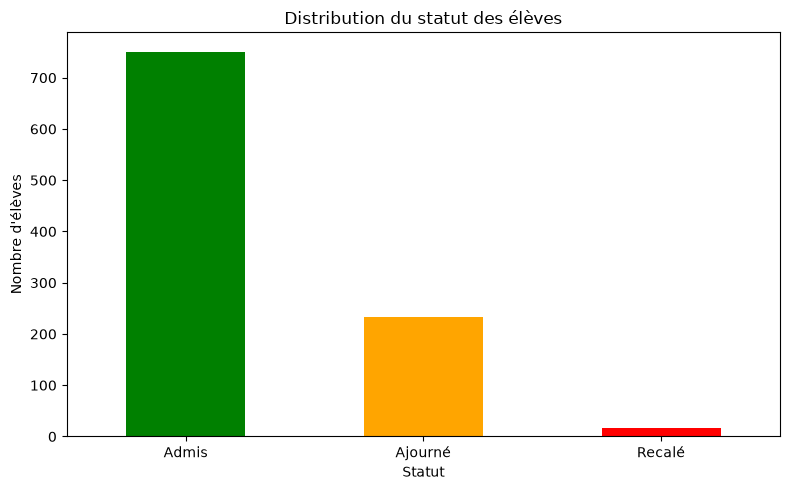

In [34]:
# Distribution of student status
print("=== Distribution du statut des élèves ===\n")
print(df_students['status'].value_counts())
print(f"\nTaux de réussite global : {round(df_students['status'].value_counts(normalize=True)['Admis'] * 100, 2)}%")

# Visualisation
plt.figure(figsize=(8, 5))
df_students['status'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Distribution du statut des élèves')
plt.xlabel('Statut')
plt.ylabel('Nombre d\'élèves')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

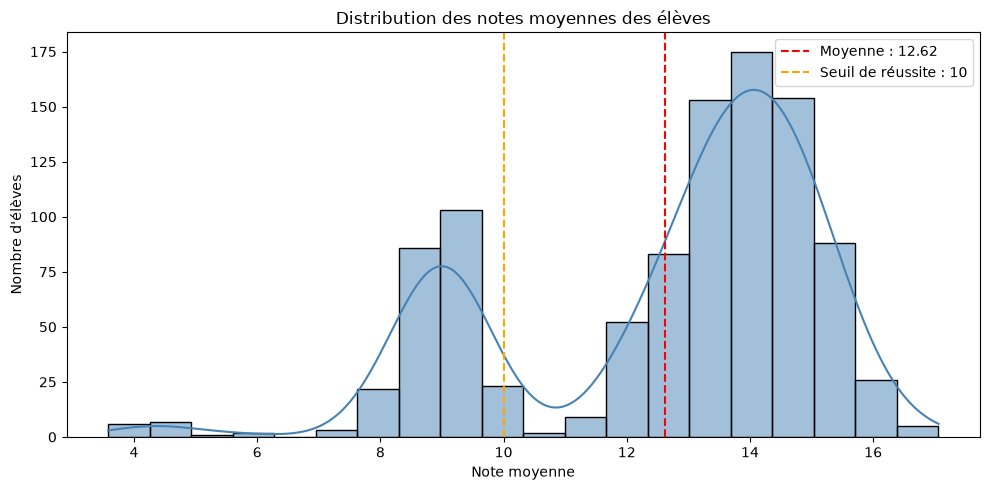

Moyenne générale : 12.62
Médiane          : 13.50
Min              : 3.58
Max              : 17.06


In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(df_students['average_score'], bins=20, kde=True, color='steelblue')
plt.title('Distribution des notes moyennes des élèves')
plt.xlabel('Note moyenne')
plt.ylabel('Nombre d\'élèves')
plt.axvline(df_students['average_score'].mean(), color='red', linestyle='--', label=f"Moyenne : {df_students['average_score'].mean():.2f}")
plt.axvline(10, color='orange', linestyle='--', label='Seuil de réussite : 10')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Moyenne générale : {df_students['average_score'].mean():.2f}")
print(f"Médiane          : {df_students['average_score'].median():.2f}")
print(f"Min              : {df_students['average_score'].min():.2f}")
print(f"Max              : {df_students['average_score'].max():.2f}")

=== Taux de réussite par niveau ===

grade_level
1ère Bac        73.77
2ème Bac        76.75
3ème Collège    76.99
Tronc Commun    72.76
Name: status, dtype: float64


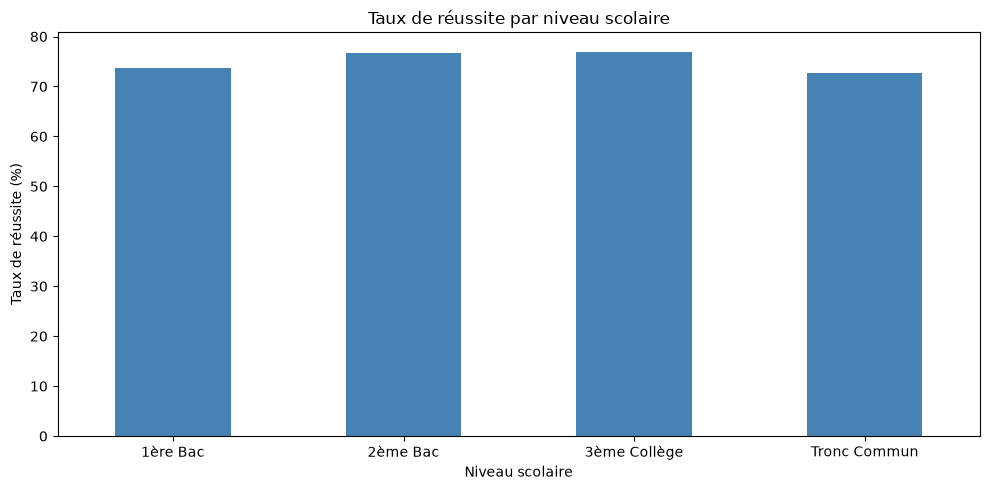

In [36]:
# Success rate per grade level
success_by_level = df_students.groupby('grade_level')['status'].apply(
    lambda x: round((x == 'Admis').sum() / len(x) * 100, 2)
)

print("=== Taux de réussite par niveau ===\n")
print(success_by_level)

# Visualisation
plt.figure(figsize=(10, 5))
success_by_level.plot(kind='bar', color='steelblue')
plt.title('Taux de réussite par niveau scolaire')
plt.xlabel('Niveau scolaire')
plt.ylabel('Taux de réussite (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== Taux de réussite par genre ===

gender
F    74.13
M    76.03
Name: status, dtype: float64


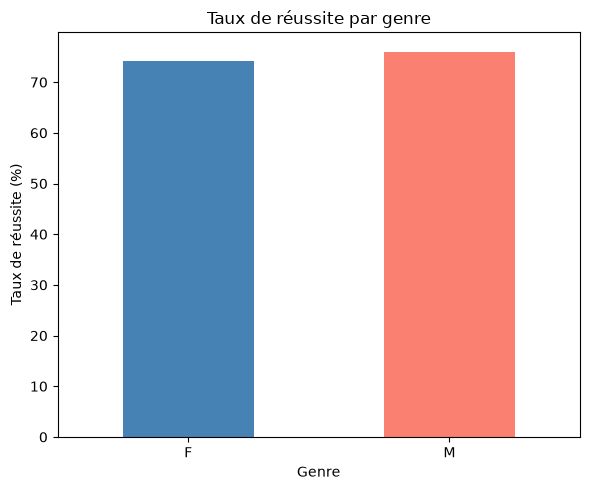

In [37]:
# Success rate by gender
success_by_gender = df_students.groupby('gender')['status'].apply(
    lambda x: round((x == 'Admis').sum() / len(x) * 100, 2)
)

print("=== Taux de réussite par genre ===\n")
print(success_by_gender)

# Visualisation
plt.figure(figsize=(6, 5))
success_by_gender.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Taux de réussite par genre')
plt.xlabel('Genre')
plt.ylabel('Taux de réussite (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== Taux de réussite par accès à internet ===

internet_access
Non    73.77
Oui    76.47
Name: status, dtype: float64


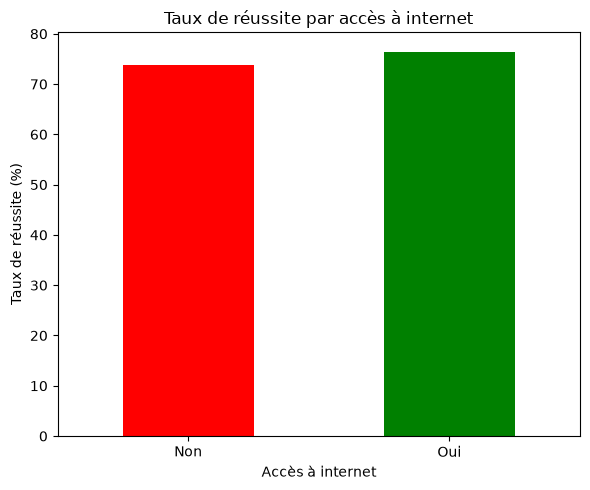

In [38]:
# Success rate by internet access
success_by_internet = df_students.groupby('internet_access')['status'].apply(
    lambda x: round((x == 'Admis').sum() / len(x) * 100, 2)
)

print("=== Taux de réussite par accès à internet ===\n")
print(success_by_internet)

# Visualisation
plt.figure(figsize=(6, 5))
success_by_internet.plot(kind='bar', color=['red', 'green'])
plt.title('Taux de réussite par accès à internet')
plt.xlabel('Accès à internet')
plt.ylabel('Taux de réussite (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== Taux de réussite par niveau d'éducation des parents ===

parent_education
Aucun         78.03
Primaire      73.66
Secondaire    73.02
Supérieur     74.56
Name: status, dtype: float64


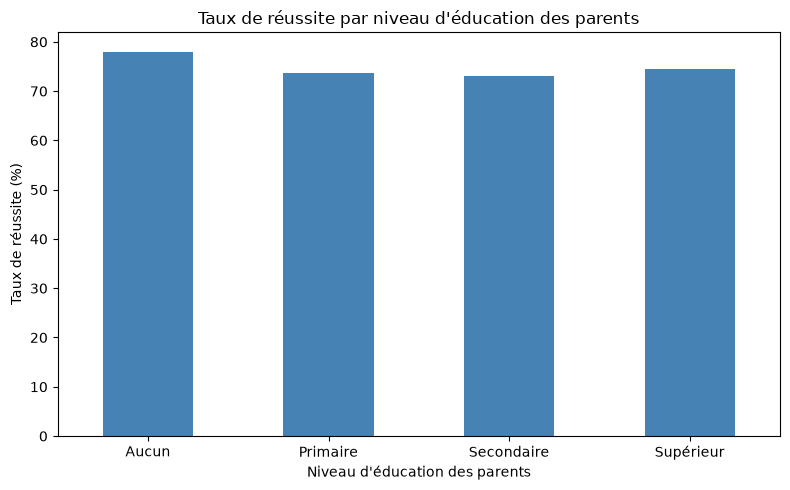

In [39]:
# Success rate by parent education level
success_by_parent = df_students.groupby('parent_education')['status'].apply(
    lambda x: round((x == 'Admis').sum() / len(x) * 100, 2)
)

print("=== Taux de réussite par niveau d'éducation des parents ===\n")
print(success_by_parent)

# Visualisation
plt.figure(figsize=(8, 5))
success_by_parent.plot(kind='bar', color='steelblue')
plt.title("Taux de réussite par niveau d'éducation des parents")
plt.xlabel("Niveau d'éducation des parents")
plt.ylabel('Taux de réussite (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== Corrélation assiduité / moyenne générale ===

Coefficient de corrélation : 0.39


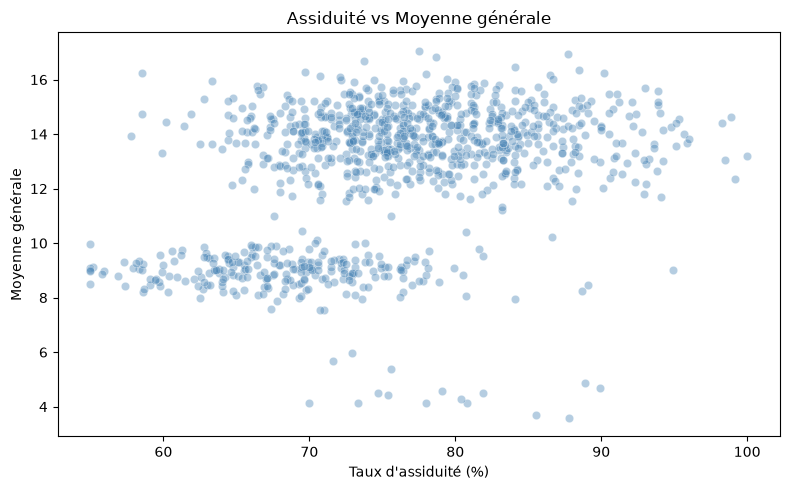

In [40]:
# Correlation between attendance and average score
correlation = df_students['attendance_pct'].corr(df_students['average_score'])
print(f"=== Corrélation assiduité / moyenne générale ===\n")
print(f"Coefficient de corrélation : {round(correlation, 2)}")

# Visualisation
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_students, x='attendance_pct', y='average_score', alpha=0.4, color='steelblue')
plt.title('Assiduité vs Moyenne générale')
plt.xlabel('Taux d\'assiduité (%)')
plt.ylabel('Moyenne générale')
plt.tight_layout()
plt.show()

=== Corrélation heures d'étude / moyenne générale ===

Coefficient de corrélation : 0.78


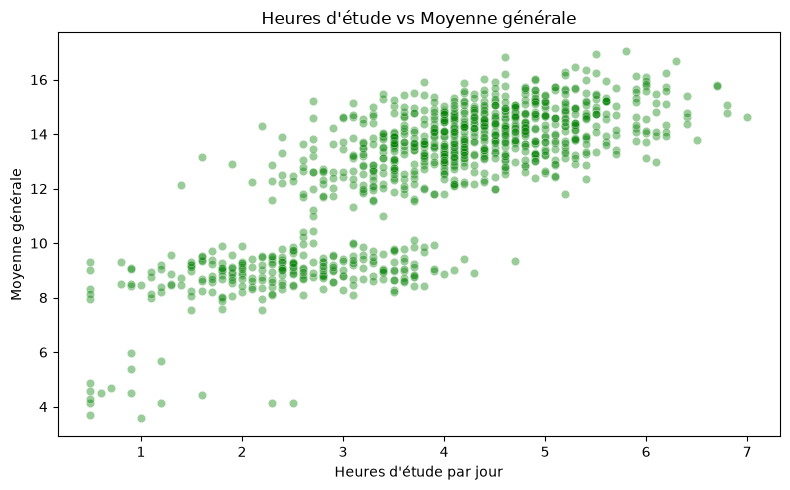

In [43]:
# Correlation between study hours and average score
correlation = df_students['study_hours_per_day'].corr(df_students['average_score'])
print(f"=== Corrélation heures d'étude / moyenne générale ===\n")
print(f"Coefficient de corrélation : {round(correlation, 2)}")

# Visualisation
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_students, x='study_hours_per_day', y='average_score', alpha=0.4, color='green')
plt.title("Heures d'étude vs Moyenne générale")
plt.xlabel("Heures d'étude par jour")
plt.ylabel('Moyenne générale')
plt.tight_layout()
plt.show()

In [44]:
# Join students with schools
df_merged = df_students.merge(df_schools[['school_id', 'milieu', 'school_type', 'region']], 
                               on='school_id', 
                               how='left')

print(f"✅ Jointure effectuée : {df_merged.shape}")
print(f"\nMilieu unique values : {df_merged['milieu'].unique()}")

✅ Jointure effectuée : (1000, 22)

Milieu unique values : ['Rural' 'Urbain']


=== Taux de réussite : Urbain vs Rural ===

milieu
Rural     73.53
Urbain    77.12
Name: status, dtype: float64


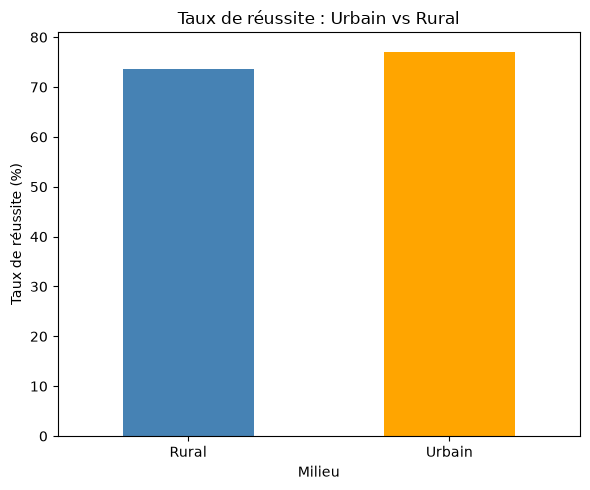

In [45]:
# Success rate by milieu (urban vs rural)
success_by_milieu = df_merged.groupby('milieu')['status'].apply(
    lambda x: round((x == 'Admis').sum() / len(x) * 100, 2)
)

print("=== Taux de réussite : Urbain vs Rural ===\n")
print(success_by_milieu)

# Visualisation
plt.figure(figsize=(6, 5))
success_by_milieu.plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Taux de réussite : Urbain vs Rural')
plt.xlabel('Milieu')
plt.ylabel('Taux de réussite (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== Taux de réussite par type d'établissement ===

school_type
Privé     72.91
Public    77.31
Name: status, dtype: float64


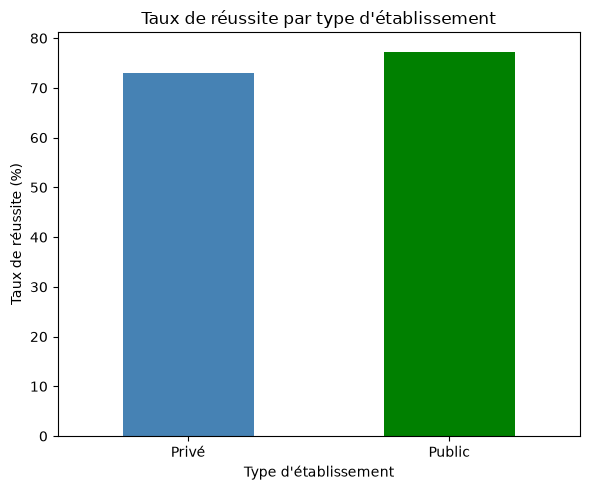

In [46]:
# Success rate by school type (public vs private)
success_by_type = df_merged.groupby('school_type')['status'].apply(
    lambda x: round((x == 'Admis').sum() / len(x) * 100, 2)
)

print("=== Taux de réussite par type d'établissement ===\n")
print(success_by_type)

# Visualisation
plt.figure(figsize=(6, 5))
success_by_type.plot(kind='bar', color=['steelblue', 'green'])
plt.title("Taux de réussite par type d'établissement")
plt.xlabel("Type d'établissement")
plt.ylabel('Taux de réussite (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

✅ Jointure complète : (1000, 30)

=== Taux de réussite par région ===

region
Casablanca-Settat            79.25
Rabat-Salé-Kénitra           78.67
Béni Mellal-Khénifra         77.97
Marrakech-Safi               77.14
Souss-Massa                  76.00
Tanger-Tétouan-Al Hoceïma    74.63
Fès-Meknès                   73.08
Oriental                     65.65
Name: status, dtype: float64


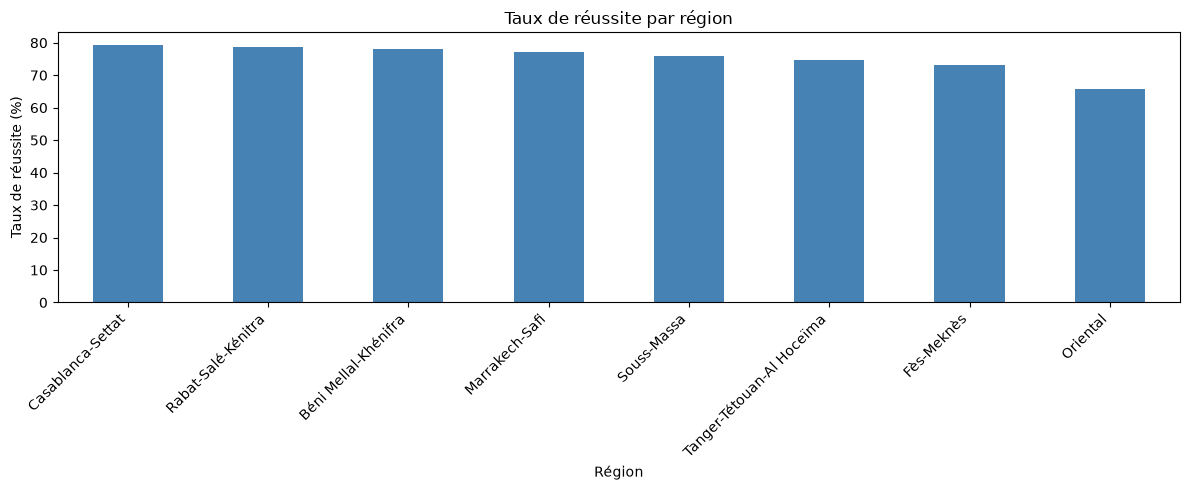

In [47]:
# Join merged dataframe with regional stats
df_full = df_merged.merge(df_regions, on='region', how='left')

print(f"✅ Jointure complète : {df_full.shape}")

# Success rate by region
success_by_region = df_full.groupby('region')['status'].apply(
    lambda x: round((x == 'Admis').sum() / len(x) * 100, 2)
).sort_values(ascending=False)

print("\n=== Taux de réussite par région ===\n")
print(success_by_region)

# Visualisation
plt.figure(figsize=(12, 5))
success_by_region.plot(kind='bar', color='steelblue')
plt.title('Taux de réussite par région')
plt.xlabel('Région')
plt.ylabel('Taux de réussite (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

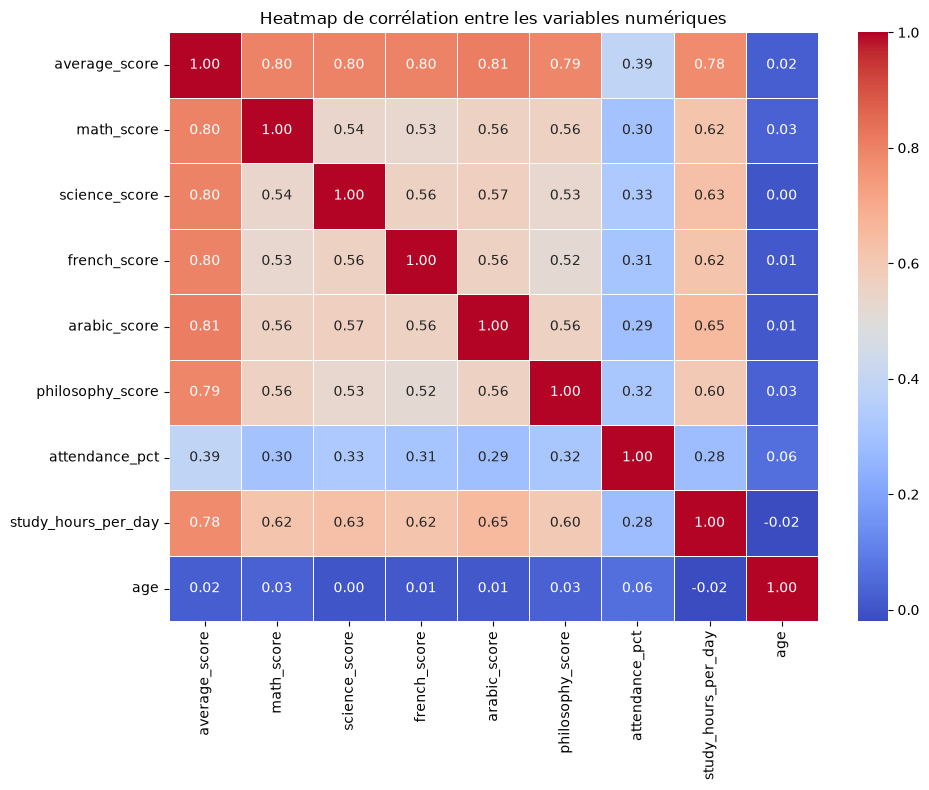

In [48]:
# Select only numeric columns for correlation
numeric_cols = ['average_score', 'math_score', 'science_score', 'french_score',
                'arabic_score', 'philosophy_score', 'attendance_pct',
                'study_hours_per_day', 'age']

# Compute correlation matrix
corr_matrix = df_students[numeric_cols].corr().round(2)

# Visualisation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap de corrélation entre les variables numériques')
plt.tight_layout()
plt.show()

=== Segmentation par niveau de risque ===

risk_level
Risque faible    734
Risque modéré    253
Risque élevé      13
Name: count, dtype: int64


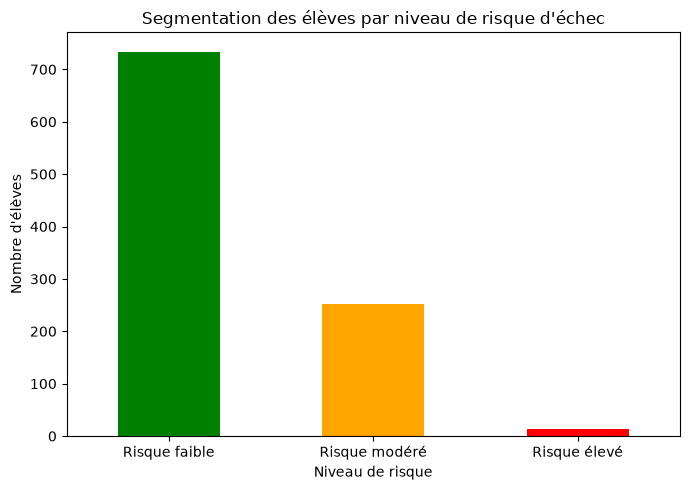

In [49]:
# Step 1 : compute risk score for each student (0 = low risk, 1 = high risk)
df_students['risk_score'] = (
    (1 - (df_students['average_score'] / 20)) * 0.5 +
    (1 - (df_students['attendance_pct'] / 100)) * 0.3 +
    (1 - (df_students['study_hours_per_day'] / 7)) * 0.2
)

# Step 2 : classify into 3 risk levels
def classify_risk(score):
    if score >= 0.6:
        return 'Risque élevé'
    elif score >= 0.4:
        return 'Risque modéré'
    else:
        return 'Risque faible'

df_students['risk_level'] = df_students['risk_score'].apply(classify_risk)

# Step 3 : show results
print("=== Segmentation par niveau de risque ===\n")
print(df_students['risk_level'].value_counts())

# Visualisation
plt.figure(figsize=(7, 5))
df_students['risk_level'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title("Segmentation des élèves par niveau de risque d'échec")
plt.xlabel('Niveau de risque')
plt.ylabel("Nombre d'élèves")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()